Iteration 1: Best Distance = 26.41
Iteration 2: Best Distance = 26.41
Iteration 3: Best Distance = 26.41
Iteration 4: Best Distance = 26.41
Iteration 5: Best Distance = 26.41
Iteration 6: Best Distance = 26.41
Iteration 7: Best Distance = 26.41
Iteration 8: Best Distance = 26.41
Iteration 9: Best Distance = 26.41
Iteration 10: Best Distance = 26.41
Iteration 11: Best Distance = 26.41
Iteration 12: Best Distance = 26.41
Iteration 13: Best Distance = 26.41
Iteration 14: Best Distance = 26.41
Iteration 15: Best Distance = 26.41
Iteration 16: Best Distance = 26.41
Iteration 17: Best Distance = 26.41
Iteration 18: Best Distance = 26.41
Iteration 19: Best Distance = 26.41
Iteration 20: Best Distance = 26.41
Iteration 21: Best Distance = 26.41
Iteration 22: Best Distance = 26.41
Iteration 23: Best Distance = 26.41
Iteration 24: Best Distance = 26.41
Iteration 25: Best Distance = 26.41
Iteration 26: Best Distance = 26.41
Iteration 27: Best Distance = 26.41
Iteration 28: Best Distance = 26.41
I

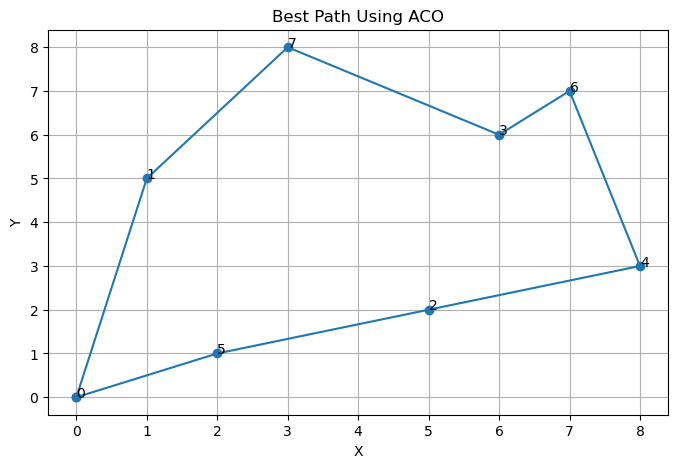

In [6]:
# ---------------------------------------------------------
# ANT COLONY OPTIMIZATION FOR TSP
# ---------------------------------------------------------

import numpy as np
import random
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Step 1 : Define Cities
# ---------------------------------------------------------

cities = np.array([
    [0, 0],
    [1, 5],
    [5, 2],
    [6, 6],
    [8, 3],
    [2, 1],
    [7, 7],
    [3, 8]
])

num_cities = len(cities)

# ---------------------------------------------------------
# Step 2 : Create Distance Matrix
# ---------------------------------------------------------

distance = np.linalg.norm(
    cities[:, np.newaxis] - cities[np.newaxis, :],
    axis=2
)

# Avoid division by zero
np.fill_diagonal(distance, 1)

# ---------------------------------------------------------
# Step 3 : Parameters
# ---------------------------------------------------------

num_ants = 10
iterations = 50

alpha = 1
beta = 5

evaporation = 0.5
Q = 100

# Initial pheromone
pheromone = np.ones((num_cities, num_cities))

best_path = None
best_distance = float("inf")

# ---------------------------------------------------------
# Step 4 : Path Distance
# ---------------------------------------------------------

def get_distance(path):
    total = 0
    for i in range(len(path) - 1):
        total += distance[path[i]][path[i + 1]]
    return total

# ---------------------------------------------------------
# Step 5 : Generate Path
# ---------------------------------------------------------

def generate_path():
    start = random.randint(0, num_cities - 1)
    path = [start]

    unvisited = list(set(range(num_cities)) - {start})

    while unvisited:
        current = path[-1]
        probabilities = []

        for city in unvisited:
            tau = pheromone[current][city] ** alpha
            eta = (1 / distance[current][city]) ** beta
            probabilities.append(tau * eta)

        probabilities = np.array(probabilities)
        probabilities = probabilities / probabilities.sum()

        next_city = np.random.choice(unvisited, p=probabilities)

        path.append(next_city)
        unvisited.remove(next_city)

    path.append(path[0])
    return path

# ---------------------------------------------------------
# Step 6 : Main ACO Loop
# ---------------------------------------------------------

for iteration in range(iterations):
    all_paths = []
    all_lengths = []

    for ant in range(num_ants):
        path = generate_path()
        length = get_distance(path)

        all_paths.append(path)
        all_lengths.append(length)

        if length < best_distance:
            best_distance = length
            best_path = path

    # Evaporation
    pheromone *= (1 - evaporation)

    # Update pheromone
    for path, length in zip(all_paths, all_lengths):
        for i in range(len(path) - 1):
            a = path[i]
            b = path[i + 1]

            pheromone[a][b] += Q / length
            pheromone[b][a] += Q / length

    print(f"Iteration {iteration + 1}: Best Distance = {best_distance:.2f}")

# ---------------------------------------------------------
# Step 7 : Final Output
# ---------------------------------------------------------

print("\nBest Path :", best_path)
print("Shortest Distance :", round(best_distance, 2))

# ---------------------------------------------------------
# Step 8 : Visualization
# ---------------------------------------------------------

x = [cities[i][0] for i in best_path]
y = [cities[i][1] for i in best_path]

plt.figure(figsize=(8, 5))
plt.plot(x, y, marker='o')

for i in range(num_cities):
    plt.text(cities[i][0], cities[i][1], str(i))

plt.title("Best Path Using ACO")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid()
plt.show()